# Bayesian Estimation of a Sticky-Wage HANK Model

**Google Colab version** — self-contained, no local dependencies required.

Run the setup cell below first, then run all cells. Tier 2 estimation takes ~60-90 min on Colab CPU.

In [ ]:
# ============================================================
# COLAB SETUP — run this cell first
# ============================================================
!pip install -q sequence-jacobian pandas-datareader statsmodels tqdm numba

import os
os.makedirs('results', exist_ok=True)

In [ ]:
# General python packages
import sys, copy, time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import scipy.optimize as opt
import statsmodels.api as sm

# sequence_jacobian v1.0 (shade-econ)
import sequence_jacobian as sj
from sequence_jacobian import simple, het, solved
import sequence_jacobian.utilities as sj_utils
from sequence_jacobian import estimation as ssj_est

# hetmacro stubs (only used in optional validation cell, not estimation)
# On Colab we skip the hetmacro comparison — the SSJ pipeline is self-contained.
hm_rouwenhorst = None
hm_make_asset_grid = None
hm_backward_egm = None

# Plot formatting
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['axes.xmargin'] = 0
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=10)

print("Imports OK (Colab mode — hetmacro stubs active)")

---
## 1. Data Preparation

US quarterly data: inflation, log real GDP (detrended), nominal interest rate, 1966Q1-2004Q4.

In [2]:
try:
    import pandas_datareader.data as web
    from datetime import datetime
    start, end = datetime(1966, 1, 1), datetime(2004, 12, 31)

    gdp_defl = web.DataReader('GDPDEF', 'fred', start, end).resample('QS').first()
    pi_data = gdp_defl.pct_change().dropna().values.flatten()

    rgdp = web.DataReader('GDPC1', 'fred', start, end).resample('QS').first()
    log_gdp = np.log(rgdp.values.flatten())
    t_trend = np.arange(len(log_gdp))
    slope, intercept = np.polyfit(t_trend, log_gdp, 1)
    y_data = (log_gdp - (slope * t_trend + intercept))

    ffr = web.DataReader('FEDFUNDS', 'fred', start, end).resample('QS').mean().values.flatten() / 400

    n = min(len(pi_data), len(y_data) - 1, len(ffr))
    data_real = np.column_stack([pi_data[:n] - np.mean(pi_data[:n]),
                                  y_data[1:n+1] - np.mean(y_data[1:n+1]),
                                  ffr[:n] - np.mean(ffr[:n])])
    USE_REAL_DATA = True
    print(f"Real data loaded: {data_real.shape}")
except Exception as e:
    print(f"FRED data unavailable ({e}). Using simulated data only.")
    USE_REAL_DATA = False

Real data loaded: (155, 3)


In [ ]:
if USE_REAL_DATA:
    import pandas as pd
    quarters = pd.date_range('1966Q1', periods=data_real.shape[0], freq='QS')
    labels = ['Inflation (demeaned)', 'Detrended log GDP (demeaned)', 'Fed funds rate (demeaned)']
    colors = ['tab:blue', 'tab:orange', 'tab:green']

    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
    for k, (ax, lab, col) in enumerate(zip(axes, labels, colors)):
        ax.plot(quarters, data_real[:, k], color=col, lw=1.2)
        ax.axhline(0, color='k', lw=0.5, ls='--')
        ax.set_ylabel(lab, fontsize=9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))
    axes[0].set_title('US quarterly data: 1966Q1–2004Q4', fontsize=11)
    axes[-1].set_xlabel('Quarter')
    plt.tight_layout()
    plt.savefig('real_data_series.pdf', bbox_inches='tight')
    plt.show()

---
## 2. Model Definition: Sticky-Wage HANK

**Household**: CRRA utility, Rouwenhorst income, borrowing constraint, EGM solution
**Wage Phillips curve**: $\pi_t^w = \kappa_w(MRS - w/\mu) + \beta \pi_{t+1}^w$
**Taylor rule**: $i_t = r_{ss} + \phi_\pi \pi_t + \varepsilon_t$, Fisher: $r_t = i_t - \pi_{t+1}$
**Fiscal**: $T_t = T_{ss} + \phi_T(B_{t-1} - \bar{B})$, $B_t = (1+r_{t-1})B_{t-1} + G_t - T_t$
**Clearing**: $C + G = Y$ (goods), $A = B$ (assets)
**Shocks**: $\varepsilon_t, X_t, G_t$ all AR(1)

**DAG**: exogenous $\mathcal{Z}=\{\varepsilon, X, G\}$, unknowns $\mathcal{U}=\{Y, \pi\}$, targets $\mathcal{H}=\{$asset_mkt, piwres$\}$

In [3]:
# --- Grid construction ---
@simple
def construct_grids(amax, amin, rho_e, sd_e, nA, nS):
    a_grid = sj_utils.discretize.agrid(amax=amax, n=nA, amin=amin)
    e_grid, e_pdf, Pi = sj_utils.discretize.markov_rouwenhorst(rho=rho_e, sigma=sd_e, N=nS)
    return a_grid, e_grid, e_pdf, Pi

In [4]:
# --- Household HA block ---
def income_incidence(e_grid, Y, T):
    y_grid = (Y - T) * e_grid
    return y_grid

def household_init(rpost, Y, T, sigma, a_grid, e_grid):
    coh = (1 + rpost) * a_grid[np.newaxis, :] + (Y - T) * e_grid[:, np.newaxis]
    Va = (1 + rpost) * (0.2 * coh) ** (-sigma)
    return Va

@het(exogenous='Pi', policy='a', backward='Va', backward_init=household_init,
     hetinputs=[income_incidence])
def household(Va_p, a_grid, acons, e_grid, y_grid, rpost, beta, sigma):
    """Single backward EGM step with CRRA utility.

    Note: Va_p already includes the expectation E[Va'|e] = Pi @ Va,
    applied automatically by the @het decorator.
    """
    uc_nextgrid = beta * Va_p
    c_nextgrid = uc_nextgrid ** (-1 / sigma)
    lhs = c_nextgrid + a_grid[np.newaxis, :] - y_grid[:, np.newaxis]
    rhs = (1 + rpost) * a_grid
    a = sj.interpolate.interpolate_y(lhs, rhs, a_grid)
    sj.misc.setmin(a, acons)
    c = rhs[np.newaxis, :] + y_grid[:, np.newaxis] - a
    uc = c ** (-sigma)
    Va = (1 + rpost) * uc
    uce = uc * e_grid[:, np.newaxis]
    return Va, a, c, uc, uce

In [5]:
# --- Household RA block ---
@solved(unknowns={'C': 1., 'A': 1.}, targets=['Cres', 'Ares'], solver="broyden_custom")
def household_ra(C, A, r, rpost, Y, T, beta, sigma):
    Cres = beta * (1 + r) * C(1)**(-sigma) - C**(-sigma)
    Ares = (1 + rpost) * A(-1) + Y - T - C - A
    return Cres, Ares

In [6]:
# --- Aggregate blocks ---
@simple
def rpost_simple(r):
    rpost = r(-1)
    return rpost

@simple
def monetary_taylor(pi, ishock, rss, phi_pi):
    i = rss + phi_pi * pi + ishock
    r = i - pi(1)
    return i, r

@simple
def nkpc(pi, Y, X, C, kappa_w, vphi, frisch, markup_ss, eis, beta):
    piw = pi + X - X(-1)
    N = Y / X
    piwres = kappa_w * (vphi * N**(1/frisch) - 1/markup_ss * X * C**(-1/eis)) + beta * piw(1) - piw
    return piwres, piw, N

@simple
def mkt_clearing(A, B, Y, C, G):
    asset_mkt = A - B
    goods_mkt = C + G - Y
    return asset_mkt, goods_mkt

@solved(unknowns={'B': 0}, targets=['Bres'], solver="brentq")
def fiscal_TBrule(r, G, B, Tss, phi_T):
    T = Tss + phi_T * (B(-1) - B.ss)
    Bres = (1 + r(-1)) * B(-1) + G - T - B
    return T, Bres

In [7]:
# --- DAG setup ---
blocks_ha = [household, mkt_clearing, nkpc, rpost_simple, monetary_taylor, fiscal_TBrule]
blocks_ra = [household_ra, mkt_clearing, nkpc, rpost_simple, monetary_taylor, fiscal_TBrule]

exogenous = ['ishock', 'X', 'G']
unknowns = ['Y', 'pi']
targets = ['asset_mkt', 'piwres']

# Create model objects (v1.0 API)
model_ha = sj.create_model(blocks_ha)
model_ra = sj.create_model(blocks_ra)
print("Models created")

Models created


In [8]:
# Visualize DAG
sj.drawdag(blocks_ha + [construct_grids])

/opt/anaconda3/lib/python3.12/site-packages/sequence_jacobian/utilities/drawdag.py:98: UserWarning: 
Attempted to use `drawdag` when the package `graphviz` has not yet been installed. 
DAG visualization tools, i.e. drawdag, will not produce any figures unless this dependency has been installed. 
If you want to install, try typing 'conda install -c conda-forge python-graphviz' at the terminal,
or see README for more instructions. Once installed, re-load sequence-jacobian to produce DAG figures.


---
## 3. Steady State Calibration

In [9]:
from sequence_jacobian.classes.steady_state_dict import SteadyStateDict

def build_calibration(model='ha', amin=-1, phi_T=0.1, B=0, G=0,
                     beta_min=0.75, beta_max=0.85, nA=500, kappa_w=0.2, phi_pi=1.5):
    """Build calibration dict and compute steady state."""

    calib = {"sigma": 2, "r": 0.01, "rho_e": 0.92, "sd_e": 0.92,
             "Y": 1, 'N': 1, 'X': 1, 'G': G, 'B': B, 'phi_T': phi_T,
             'kappa_w': kappa_w, 'frisch': 0.5, 'markup_ss': 1.015, 'phi_pi': phi_pi,
             "nS": 11, "amax": 1000, "amin": amin, "nA": nA, 'acons': amin}

    calib['w'] = calib['X']
    calib['rss'] = calib['r']
    calib['rpost'] = calib['r']
    calib['T'] = calib['r'] * calib['B'] + calib['G']
    calib.update({'Tss': calib['T'], 'Gss': calib['G']})
    calib['eis'] = 1 / calib['sigma']

    if model == 'ha':
        ha_model = sj.create_model([household, mkt_clearing, construct_grids])
        ss = ha_model.solve_steady_state(
            calib, {"beta": (beta_min, beta_max)}, ["asset_mkt"],
            solver="brentq"
        )
        # Add nominal side, preserving het block internals
        ss_dict = dict(ss)
        ss_dict.update({'pi': 0, 'piw': 0, 'ishock': 0})
        ss_dict['i'] = ss_dict['r'] + ss_dict['pi']
        ss_dict['vphi'] = (ss_dict['Y'] / ss_dict['N'] * 1 / ss_dict['markup_ss']
                           * ss_dict['C']**(-1/ss_dict['eis']) * ss_dict['N']**(-1/ss_dict['frisch']))
        ss_out = SteadyStateDict(ss_dict, internals=ss.internals)
    else:
        calib['beta'] = 1 / (1 + calib['r'])
        calib['A'] = calib['B']
        calib['C'] = calib['Y'] - calib['G']
        calib.update({'pi': 0, 'piw': 0, 'ishock': 0, 'i': calib['r']})
        calib['vphi'] = (calib['Y'] / calib['N'] * 1 / calib['markup_ss']
                         * calib['C']**(-1/calib['eis']) * calib['N']**(-1/calib['frisch']))
        ss_out = SteadyStateDict(calib)

    print(f"  {model.upper()}: beta={ss_out['beta']:.6f}, C={ss_out['C']:.4f}, A={ss_out['A']:.4f}")
    print(f"  Walras: {ss_out['Y'] - ss_out['C'] - ss_out['G']:.2e}")
    return ss_out

In [10]:
print("Calibrating steady states...")
ss_ha = build_calibration(model='ha')
ss_ra = build_calibration(model='ra')

Calibrating steady states...
  HA: beta=0.823352, C=1.0000, A=0.0000
  Walras: -1.18e-10
  RA: beta=0.990099, C=1.0000, A=0.0000
  Walras: 0.00e+00


---
## 2b. hetmacro Side-by-Side Verification

In [ ]:
# --- Cross-validation with hetmacro (SKIPPED on Colab) ---
# This cell compares sequence_jacobian vs hetmacro implementations.
# Requires the hetmacro package (not available on Colab).
# The estimation pipeline uses only sequence_jacobian — this is purely a validation check.

if hm_rouwenhorst is not None:
    # Rouwenhorst comparison
    rho_e, sigma_cs = 0.92, 0.92
    sigma_innov = sigma_cs * np.sqrt(1 - rho_e**2)

    e_grid_sj, e_pdf_sj, Pi_sj = sj_utils.discretize.markov_rouwenhorst(rho=rho_e, sigma=sigma_cs, N=11)
    z_log_hm, Pi_hm = hm_rouwenhorst(11, rho_e, sigma_innov)
    e_grid_hm = np.exp(z_log_hm)
    e_grid_hm /= np.dot(np.linalg.matrix_power(Pi_hm.T, 1000)[:, 0], e_grid_hm)

    print("=== Rouwenhorst ===")
    print(f"  Pi diff:     {np.max(np.abs(Pi_sj - Pi_hm)):.2e}")
    print(f"  e_grid diff: {np.max(np.abs(e_grid_sj - e_grid_hm)):.2e}")
    print(f"  {'PASS' if np.max(np.abs(Pi_sj - Pi_hm)) < 1e-12 else 'FAIL'}")

    # EGM comparison
    print("\n=== EGM Backward Step ===")
    hh_int = ss_ha.internals['household']
    Va_ss = hh_int['Va']
    Pi_ss = hh_int['Pi']
    a_grid = ss_ha['a_grid']
    y_grid_ss = (ss_ha['Y'] - ss_ha['T']) * ss_ha['e_grid']
    r_ss = ss_ha['rpost']
    beta_val = ss_ha['beta']
    sigma_val = ss_ha['sigma']
    eis_val = 1 / sigma_val

    uc_ng = (beta_val * Pi_ss) @ Va_ss
    c_ng = uc_ng ** (-1 / sigma_val)
    lhs_sj = c_ng + a_grid[np.newaxis, :] - y_grid_ss[:, np.newaxis]
    rhs_sj = (1 + r_ss) * a_grid
    a_sj = sj.interpolate.interpolate_y(lhs_sj, rhs_sj, a_grid)
    sj.misc.setmin(a_sj, ss_ha['acons'])
    c_sj = rhs_sj[np.newaxis, :] + y_grid_ss[:, np.newaxis] - a_sj

    Va_hm, a_hm, c_hm = hm_backward_egm(Va_ss, Pi_ss, a_grid, y_grid_ss, r_ss, beta_val, eis_val)

    print(f"  Max |a_policy| diff: {np.max(np.abs(a_sj - a_hm)):.2e}")
    print(f"  Max |c_policy| diff: {np.max(np.abs(c_sj - c_hm)):.2e}")
    print(f"  {'PASS' if np.max(np.abs(a_sj - a_hm)) < 1e-8 else 'FAIL'}")
else:
    print("Skipped hetmacro cross-validation (Colab mode)")

---
## 4. GE Jacobians and Impulse Responses

In [12]:
T = 500
outputs = ['pi', 'Y', 'i']

import warnings; warnings.filterwarnings('ignore')

print("Computing GE Jacobians...")
t0 = time.time()
G_ha = model_ha.solve_jacobian(ss_ha, unknowns, targets, exogenous, outputs=outputs, T=T)
print(f"  HA: {time.time()-t0:.1f}s")

t0 = time.time()
G_ra = model_ra.solve_jacobian(ss_ra, unknowns, targets, exogenous, outputs=outputs, T=T)
print(f"  RA: {time.time()-t0:.1f}s")

# Walras law check (should be ~0 by construction)
G_walras = model_ha.solve_jacobian(ss_ha, unknowns, targets, exogenous, outputs=['goods_mkt'], T=T)
wmax = max(np.max(np.abs(G_walras['goods_mkt'][s])) for s in exogenous)
print(f"  Walras: {wmax:.2e} {'PASS' if wmax < 1e-8 else 'FAIL'}")

Computing GE Jacobians...
  HA: 2.0s
  RA: 0.7s
  Walras: 6.73e-10 PASS


In [13]:
def irf_make(G, shock, shockname, varlist, T):
    irf = {}
    for z in varlist:
        if z == shockname:
            irf[z] = shock
        else:
            try:
                irf[z] = G[z][shockname] @ shock
            except:
                irf[z] = np.zeros(T)
    return irf

# AR(1) shocks for visualization
shock_list = ['ishock', 'X', 'G']
rhos_calib = {'ishock': 0.7, 'X': 0.8, 'G': 0.7}
sigs_calib = {'ishock': 1.0, 'X': 0.5, 'G': 0.2}

shock = {s: sigs_calib[s] * rhos_calib[s]**np.arange(T) for s in shock_list}
varlist = ['pi', 'Y', 'i', 'C', 'N', 'B', 'T', 'r', 'piw']

irf_ha, irf_ra = {}, {}
for s in shock_list:
    irf_ha[s] = irf_make(G_ha, shock[s], s, varlist, T)
    irf_ra[s] = irf_make(G_ra, shock[s], s, varlist, T)

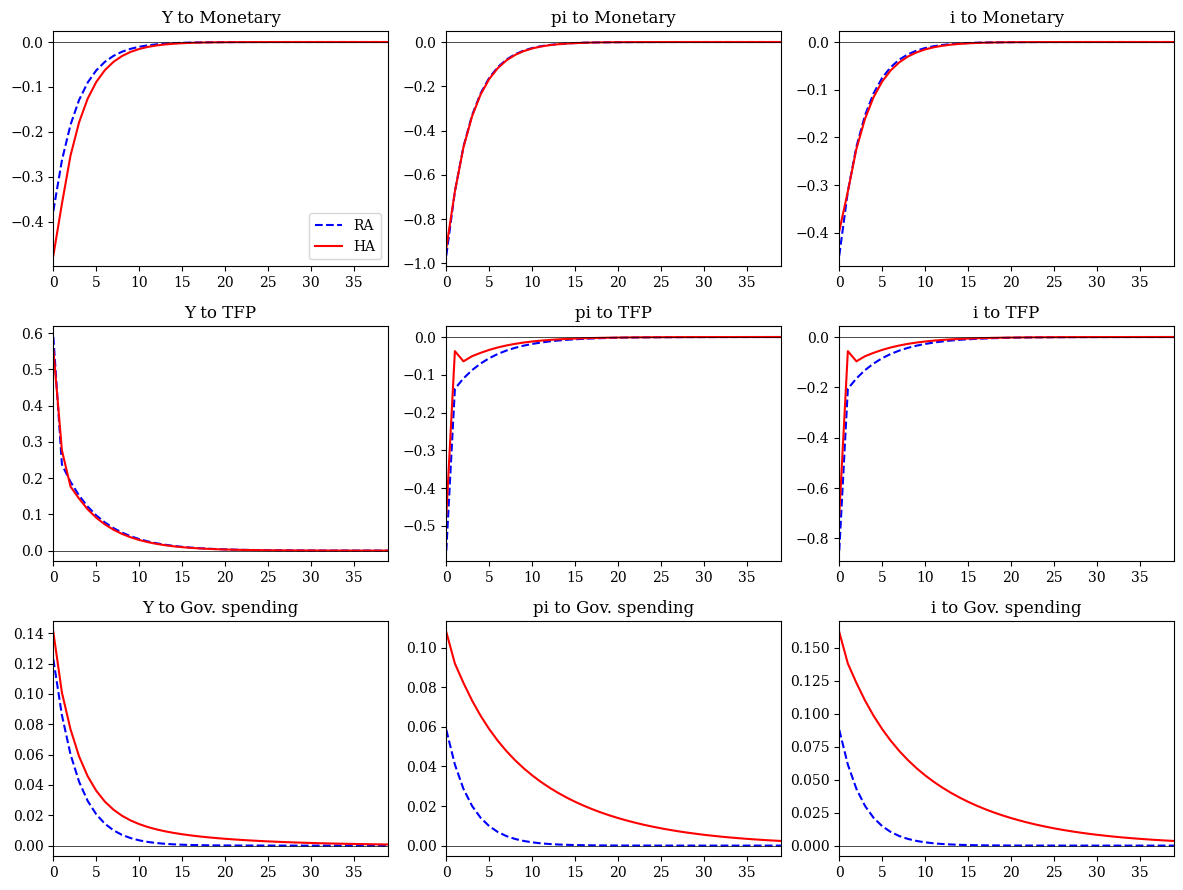

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
plot_vars = ['Y', 'pi', 'i']
shock_labels = {'ishock': 'Monetary', 'X': 'TFP', 'G': 'Gov. spending'}
T_plot = 40

for j, s in enumerate(shock_list):
    for k, v in enumerate(plot_vars):
        ax = axes[j, k]
        ax.plot(irf_ra[s][v][:T_plot], 'b--', label='RA', lw=1.5)
        ax.plot(irf_ha[s][v][:T_plot], 'r-', label='HA', lw=1.5)
        ax.axhline(0, color='k', lw=0.5)
        ax.set_title(f'{v} to {shock_labels[s]}')
        if j == 0 and k == 0: ax.legend()
plt.tight_layout()
plt.savefig('irfs_ra_vs_ha.pdf', bbox_inches='tight')
plt.show()

---
## 5. Estimation Infrastructure

**Likelihood pipeline** (refs: Macro Bible eqs. `ssj_exog_ma`, `ssj_ma_relation`, `ssj_loglikelihood`):
1. Extract shock params $\to$ MA coefficients $M_s^Z = \sigma \rho^s$
2. $M^{X|Z} = G^{X,Z} M^Z$ (GE Jacobian times exogenous MA)
3. Autocovariances from MA representation
4. Gaussian log-likelihood

In [15]:
@njit
def arma_irf(ar_coeff, ma_coeff, T):
    x = np.empty((T,))
    n_ar, n_ma = ar_coeff.size, ma_coeff.size
    for t in range(T):
        if t == 0:
            x[t] = 1
        else:
            s = 0.0
            for i in range(min(n_ar, t)):
                s += ar_coeff[i] * x[t-1-i]
            ma = ma_coeff[t-1] if 0 < t <= n_ma else 0.0
            x[t] = s + ma
    return x

def get_shocks_arma(x, shock_series):
    ix, ish = 0, 0
    sigmas = np.zeros(len(shock_series))
    arcoefs = np.zeros(len(shock_series))
    macoefs = np.zeros(len(shock_series))
    for _, order in shock_series:
        sigmas[ish] = x[ix]; ix += 1
        if order >= 1: arcoefs[ish] = x[ix]; ix += 1
        if order >= 2: macoefs[ish] = x[ix]; ix += 1
        ish += 1
    return sigmas, arcoefs, macoefs

def step1_est(G, arcoefs, macoefs, shock_series, outputs, T, T_irf, n_se, n_sh):
    As = np.empty((T_irf, n_se, n_sh))
    for i_sh in range(n_sh):
        shock_path = arma_irf(np.array([arcoefs[i_sh]]), np.array([macoefs[i_sh]]), T)
        sname = shock_series[i_sh][0]
        for i_se in range(n_se):
            As[:, i_se, i_sh] = (G[outputs[i_se]][sname] @ shock_path)[:T_irf]
    return As

In [ ]:
def log_priors(x, priors_list):
    lp = 0.0
    for n in range(len(x)):
        dist, mu, sig = priors_list[n]
        if dist == 'Uniform':
            if x[n] < mu or x[n] > sig: return -np.inf
            lp += -np.log(sig - mu)
        elif dist == 'Invgamma':
            s, v = mu, sig
            if x[n] <= 0: return -np.inf
            lp += (-v-1)*np.log(x[n]) - v*s**2/(2*x[n]**2)
        elif dist == 'Gamma':
            theta = sig**2/mu; k = mu/theta
            if x[n] <= 0: return -np.inf
            lp += (k-1)*np.log(x[n]) - x[n]/theta
        elif dist == 'Normal':
            lp += -0.5*((x[n]-mu)/sig)**2
    return lp

def loglik_f(x, data, outputs, shock_series, priors_list, T, G):
    T_irf = T - 20
    n_se, n_sh = len(outputs), len(shock_series)
    sigmas, arcoefs, macoefs = get_shocks_arma(x, shock_series)
    try:
        As = step1_est(G, arcoefs, macoefs, shock_series, outputs, T, T_irf, n_se, n_sh)
        Sigma = ssj_est.all_covariances(As, sigmas)
        To, O = data.shape
        loglik = ssj_est.log_likelihood(data, Sigma, np.zeros(n_se)) - (To*O*np.log(2*np.pi))/2
    except:
        return -1e10
    lpost = loglik + log_priors(x, priors_list)
    return lpost if np.isfinite(lpost) else -1e10

In [ ]:
class EstimationTracker:
    """Tracks optimizer progress with optional verbose output and live convergence plot."""

    def __init__(self, objective_fn, param_names=None, verbose=True, live_plot=True,
                 print_every=10, plot_every=5):
        self.objective_fn = objective_fn
        self.param_names = param_names or []
        self.verbose = verbose
        self.live_plot = live_plot
        self.print_every = print_every
        self.plot_every = plot_every
        self.history = []       # list of (iter, fval, x)
        self.iter = 0
        self.fig = None
        self.ax = None

    def callback(self, xk):
        """Called by scipy after each Nelder-Mead iteration."""
        self.iter += 1
        fval = self.objective_fn(xk)
        self.history.append((self.iter, fval, xk.copy()))

        if self.verbose and self.iter % self.print_every == 0:
            best_fval = min(h[1] for h in self.history)
            param_str = " ".join(f"{n}={v:.4f}" for n, v in zip(self.param_names, xk))
            print(f"  iter {self.iter:4d} | -logpost = {fval:12.4f} | best = {best_fval:12.4f} | {param_str}")

        if self.live_plot and self.iter % self.plot_every == 0:
            self._update_plot()

    def _update_plot(self):
        from IPython.display import clear_output, display
        iters = [h[0] for h in self.history]
        fvals = [h[1] for h in self.history]
        if self.fig is None:
            self.fig, self.ax = plt.subplots(1, 1, figsize=(8, 3))
        self.ax.clear()
        self.ax.plot(iters, fvals, 'b-', lw=1)
        self.ax.set_xlabel('Iteration')
        self.ax.set_ylabel('-log posterior')
        self.ax.set_title(f'Convergence (iter {self.iter}, best={min(fvals):.4f})')
        self.fig.tight_layout()
        clear_output(wait=True)
        display(self.fig)

    def summary(self):
        """Print convergence summary after optimization."""
        if not self.history:
            print("No iterations recorded.")
            return
        fvals = [h[1] for h in self.history]
        print(f"\nConvergence summary: {self.iter} iterations")
        print(f"  Initial -logpost: {fvals[0]:.4f}")
        print(f"  Final   -logpost: {fvals[-1]:.4f}")
        print(f"  Best    -logpost: {min(fvals):.4f}")


def hessian_numerical(f, x0, eps=1e-4):
    n = len(x0)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            xpp = x0.copy(); xpp[i] += eps; xpp[j] += eps
            xpm = x0.copy(); xpm[i] += eps; xpm[j] -= eps
            xmp = x0.copy(); xmp[i] -= eps; xmp[j] += eps
            xmm = x0.copy(); xmm[i] -= eps; xmm[j] -= eps
            H[i,j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4*eps**2)
            H[j,i] = H[i,j]
    return H

def estimate(outputs, data, x_guess, shock_series, priors_list, T,
             G=None, params=None, jac_info=None, sd=True,
             verbose=False, live_plot=False, param_names=None, **kwargs):
    if G is not None:
        objective = lambda x: -loglik_f(x, data, outputs, shock_series, priors_list, T, G)
    elif jac_info is not None:
        n_params = len(params)
        last_xp = [np.zeros(n_params)]
        last_G = [{}]
        def objective(x):
            xp = x[-n_params:]
            if not np.allclose(xp, last_xp[0], rtol=1e-12, atol=1e-12):
                ss_new = dict(jac_info['ss'])
                ss_new.update({p: xp[j] for j, p in enumerate(params)})
                from sequence_jacobian.classes.steady_state_dict import SteadyStateDict
                ss_new = SteadyStateDict(ss_new, internals=jac_info['ss'].internals)
                G_new = jac_info['model'].solve_jacobian(
                    ss_new, jac_info['unknowns'], jac_info['targets'],
                    jac_info['exogenous'], outputs=outputs, T=jac_info['T']
                )
                last_xp[0] = xp.copy()
                last_G[0] = G_new
            return -loglik_f(x, data, outputs, shock_series, priors_list, T, last_G[0])
    else:
        raise ValueError('Need G or jac_info')

    # Set up tracker for verbose/live_plot
    tracker = None
    if verbose or live_plot:
        tracker = EstimationTracker(objective, param_names=param_names or [],
                                    verbose=verbose, live_plot=live_plot)
        kwargs['callback'] = tracker.callback

    result = opt.minimize(objective, x_guess, **kwargs)

    if tracker is not None:
        # Close live plot figure cleanly
        if tracker.fig is not None:
            plt.close(tracker.fig)
        tracker.summary()

    x_sd = np.zeros_like(result.x)
    if sd:
        try:
            H = hessian_numerical(objective, result.x)
            Hinv = np.linalg.inv(H)
            x_sd = np.sqrt(np.maximum(np.diagonal(Hinv), 0))
        except:
            x_sd = np.full_like(result.x, np.nan)
    return result, x_sd, tracker

In [72]:
import pickle, os

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_results(data, filename):
    """Save estimation results to disk."""
    path = os.path.join(RESULTS_DIR, filename)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"  Saved to {path}")

def load_results(filename):
    """Load estimation results from disk."""
    path = os.path.join(RESULTS_DIR, filename)
    with open(path, 'rb') as f:
        data = pickle.load(f)
    print(f"  Loaded from {path}")
    return data

---
## 6. Simulated Data Validation

In [ ]:
@njit(parallel=True)
def simul_shock(dX, epsilon):
    dX_flipped = dX[::-1].copy()
    T_irf = len(dX); T_sim = len(epsilon)
    Y = np.empty(T_sim - T_irf + 1)
    for t in prange(T_sim - T_irf + 1):
        Y[t] = np.vdot(dX_flipped, epsilon[t:t+T_irf])
    return Y

def simulate(Gs, inputs, outputs, rhos, sigmas, T, T_simul):
    epsilons = {i: np.random.randn(T_simul + T - 1) for i in inputs}
    sims = {}
    for o in outputs:
        dXs = {i: sigmas[i]*(Gs[o][i] @ rhos[i]**np.arange(T)) for i in inputs}
        sims[o] = sum(simul_shock(dXs[i], epsilons[i]) for i in inputs)
    return sims

In [ ]:
# Simulate from known parameters
T_sim = 156
shock_series = [('ishock', 1), ('X', 1), ('G', 1)]
rhos_true = {'ishock': 0.7, 'X': 0.8, 'G': 0.7}
sigs_true = {'ishock': 1.0, 'X': 0.5, 'G': 0.2}
x_true = np.array([1.0, 0.7, 0.5, 0.8, 0.2, 0.7])

np.random.seed(42)
data_sim = simulate(G_ha, exogenous, outputs, rhos_true, sigs_true, T, T_sim)
data_simul = np.column_stack([data_sim[o] for o in outputs])

priors_shocks = [('Uniform',0,2), ('Uniform',0,1), ('Uniform',0,2),
                 ('Uniform',0,1), ('Uniform',0,2), ('Uniform',0,1)]
bounds_shocks = [(0.05,1.5),(0.01,0.99),(0.05,1.5),(0.01,0.99),(0.05,1.5),(0.01,0.99)]
param_names = ['sig_eps', 'rho_eps', 'sig_X', 'rho_X', 'sig_G', 'rho_G']

print("Estimating on simulated data...")
t0 = time.time()
result_sim, sd_sim, _ = estimate(
    outputs, data_simul, 0.9*x_true, shock_series, priors_shocks, T,
    G=G_ha, bounds=bounds_shocks, sd=True,
    verbose=True, live_plot=True, param_names=param_names,
    method='Nelder-Mead', options={'maxiter': 5000, 'xatol': 1e-5, 'fatol': 1e-5}
)
print(f"Done in {time.time()-t0:.1f}s. Converged: {result_sim.success}")
print(f"\n{'Param':<10} {'True':>8} {'Est':>8} {'SE':>8}")
print("-"*38)
for i, n in enumerate(param_names):
    print(f"{n:<10} {x_true[i]:>8.3f} {result_sim.x[i]:>8.3f} {sd_sim[i]:>8.3f}")

### 6b. Monte Carlo Posterior Validation

Re-estimate on N=40 independent simulated datasets to check that the posterior concentrates around true parameters. This produces kernel density plots matching Ludwig's 6-panel figure.

In [ ]:
from tqdm.notebook import tqdm

N_simul = 40
x_simul = np.zeros((len(x_true), N_simul))
success_simul = np.zeros(N_simul)

t0 = time.time()
for i in tqdm(range(N_simul), desc='Monte Carlo'):
    data_mc = simulate(G_ha, exogenous, outputs, rhos_true, sigs_true, T, T_sim)
    data_mc_arr = np.column_stack([data_mc[o] for o in outputs])

    res_mc, _, _ = estimate(
        outputs, data_mc_arr, 0.9*x_true, shock_series, priors_shocks, T,
        G=G_ha, bounds=bounds_shocks, sd=False,
        method='Nelder-Mead', options={'maxiter': 5000, 'xatol': 1e-5, 'fatol': 1e-5})

    success_simul[i] = res_mc.success
    x_simul[:, i] = res_mc.x

print(f"MC done: {time.time()-t0:.0f}s, {success_simul.sum():.0f}/{N_simul} converged")

In [ ]:
# Kernel density plots: row 1 = s.d.'s, row 2 = AR(1) coefficients
plt_titles = ['Monetary shock s.d.', 'Productivity shock s.d.', 'G shock s.d.',
              'Monetary shock AR(1)', 'Productivity shock AR(1)', 'G shock AR(1)']
# x_true ordering: [sig_eps, rho_eps, sig_X, rho_X, sig_G, rho_G]
# Desired layout: row 1 = s.d.'s (indices 0,2,4), row 2 = AR-1's (indices 1,3,5)
idx = [0, 2, 4, 1, 3, 5]

fig, axes = plt.subplots(2, 3, figsize=(12.5, 8))
for i, ax in enumerate(axes.flat):
    j = idx[i]
    kde = sm.nonparametric.KDEUnivariate(x_simul[j])
    kde.fit()
    ax.plot(kde.support, kde.density, 'b-', lw=1.5, label='Kernel density')
    ax.axvline(np.mean(x_simul[j]), color='tab:blue', ls=':', lw=2,
               label='Mean of re-estimations')
    ax.axvline(x_true[j], color='tab:orange', ls=':', lw=2,
               label='True parameter')
    ax.set_title(plt_titles[i])
    ax.set_xlabel('Parameter value')
    if i % 3 == 0:
        ax.set_ylabel('Density')
    if i == 4:
        ax.legend(framealpha=0, fontsize=8)

plt.suptitle(f'Monte Carlo Posterior Validation (N={N_simul})', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('mc_posterior_densities.pdf', bbox_inches='tight')
plt.show()

---
## 7. Estimation on Real Data

### 7.1 Shock Parameters Only (Tier 1)

In [ ]:
if USE_REAL_DATA:
    # Wider bounds for real data (quarterly deviations are small)
    bounds_real = [(0.001,5),(0.01,0.99),(0.001,5),(0.01,0.99),(0.001,5),(0.01,0.99)]
    priors_real = [('Invgamma',0.1,2), ('Uniform',0,1), ('Invgamma',0.1,2),
                   ('Uniform',0,1), ('Invgamma',0.1,2), ('Uniform',0,1)]

    results_shocks = {}
    for mname, G_model in [('ra', G_ra), ('ha', G_ha)]:
        print(f"--- {mname.upper()} ---")
        t0 = time.time()
        res, sd, tracker = estimate(
            outputs, data_real, np.array([0.1,0.5,0.1,0.5,0.1,0.5]), shock_series, priors_real, T,
            G=G_model, bounds=bounds_real, sd=True,
            verbose=True, live_plot=True, param_names=param_names,
            method='Nelder-Mead', options={'maxiter': 5000, 'xatol': 1e-5, 'fatol': 1e-5}
        )
        print(f"  {time.time()-t0:.1f}s, logpost={-res.fun:.2f}")
        for i, n in enumerate(param_names):
            print(f"  {n:<10} {res.x[i]:>8.4f} ({sd[i]:.4f})")
        results_shocks[mname] = (res, sd)
        print()

    # Auto-save
    save_results({'results': results_shocks, 'bounds': bounds_real, 'priors': priors_real},
                 'tier1_shocks.pkl')

### 7.2 Shock + Model Parameters (Tier 2)

Key insight: $\phi_T$ is **unidentifiable in RA** (Ricardian equivalence) but **identified in HA**.

In [ ]:
# Tier 2 is slow (~10-30 min): recomputes GE Jacobian for each model param change.
# Set RUN_TIER2 = True to run interactively.
RUN_TIER2 = True

if USE_REAL_DATA and RUN_TIER2:
    priors_ext = priors_shocks + [('Uniform',0,1), ('Gamma',1.5,0.25), ('Uniform',0,1)]
    bounds_ext = bounds_real + [(0.01,0.99), (1.01,3.0), (0.01,0.99)]
    params_est = ['kappa_w', 'phi_pi', 'phi_T']
    names_ext = param_names + params_est

    jac_info = {'model': model_ha, 'exogenous': exogenous, 'unknowns': unknowns,
                'targets': targets, 'outputs': outputs, 'T': T}

    x0_ext = np.concatenate([results_shocks['ha'][0].x, [0.2, 1.5, 0.1]])
    print("HA Tier 2 estimation (shock + model params)...")
    t0 = time.time()
    result_ext, sd_ext, tracker_ext = estimate(
        outputs, data_real, x0_ext, shock_series, priors_ext, T,
        params=params_est, jac_info=jac_info, sd=True,
        verbose=True, live_plot=True, param_names=names_ext,
        bounds=bounds_ext,
        method='Nelder-Mead', options={'maxiter': 3000, 'xatol': 1e-4, 'fatol': 1e-4}
    )
    t_ext = time.time() - t0
    print(f"\nTier 2 done in {t_ext:.0f}s")

    # Auto-save
    save_results({'result': result_ext, 'sd': sd_ext, 'params': params_est,
                  'priors': priors_ext, 'bounds': bounds_ext, 'names': names_ext},
                 'tier2_ha.pkl')
elif USE_REAL_DATA:
    print("Tier 2 estimation skipped (set RUN_TIER2 = True to run; takes ~10-30 min)")
    result_ext = None

In [75]:
# === Load saved results from disk ===
# Run this cell INSTEAD of estimation cells above to skip re-estimation.
# Requires all cells up through Section 6 (imports, data, model, SS, Jacobians,
# simulated data definitions) to have run first.

tier1_data = load_results('tier1_shocks.pkl')
results_shocks = tier1_data['results']
bounds_real = tier1_data['bounds']
priors_real = tier1_data['priors']

try:
    tier2_data = load_results('tier2_ha.pkl')
    result_ext, sd_ext = tier2_data['result'], tier2_data['sd']
    params_est = tier2_data['params']
    priors_ext, bounds_ext = tier2_data['priors'], tier2_data['bounds']
    names_ext = tier2_data['names']
except FileNotFoundError:
    print("  No Tier 2 results found on disk")
    result_ext = None

  Loaded from results/tier1_shocks.pkl
  Loaded from results/tier2_ha.pkl


### 7.3 Marginal Log-Posterior Profiles

For each parameter, sweep a grid while holding others at their posterior mode. If the posterior is well behaved, each slice should peak at the mode.

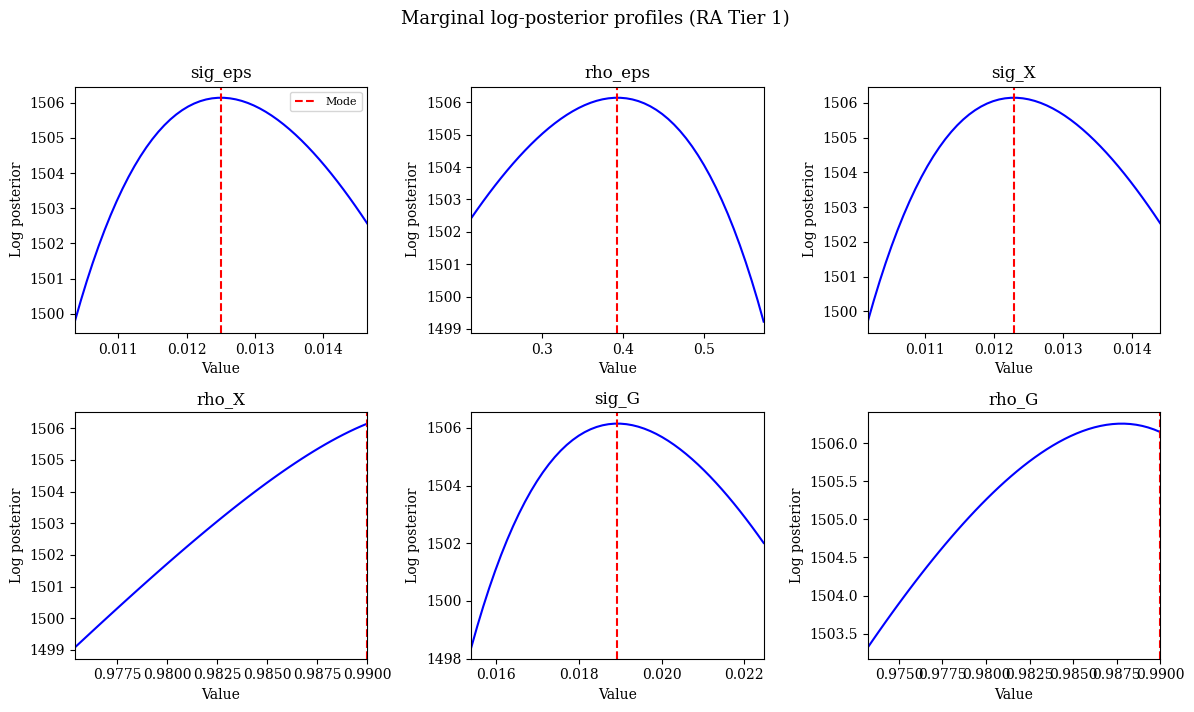

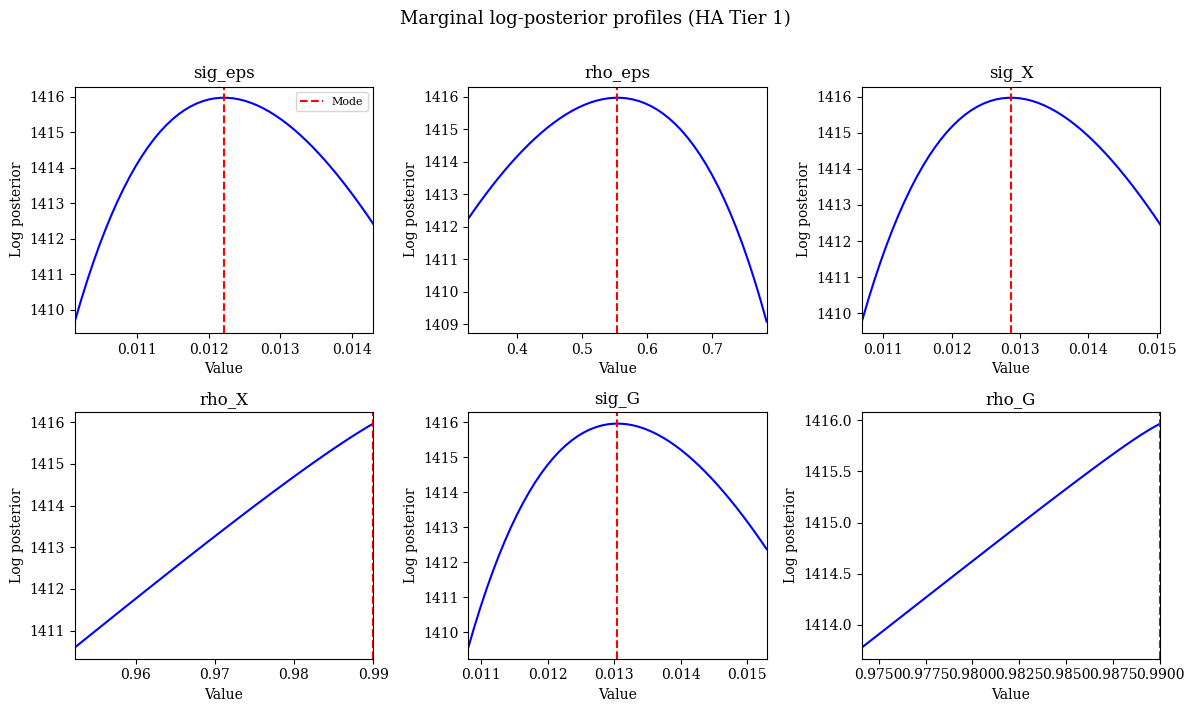

In [76]:
def plot_marginal_logpost(x_mode, pnames, logpost_func, n_grid=50, n_sigma=3, x_sd=None,
                          bounds=None, title='Marginal log-posterior profiles'):
    """Plot 1D log-posterior profiles for each parameter."""
    n_params = len(x_mode)
    ncols = min(3, n_params)
    nrows = (n_params + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
    if n_params == 1:
        axes = [axes]
    else:
        axes = axes.flat

    for i in range(n_params):
        # Grid: +/- 3 SE (or +/- 30% if SE unavailable)
        if x_sd is not None and x_sd[i] > 0 and np.isfinite(x_sd[i]):
            lo = max(x_mode[i] - n_sigma * x_sd[i], 0.001)
            hi = x_mode[i] + n_sigma * x_sd[i]
        else:
            lo, hi = 0.7 * x_mode[i], 1.3 * x_mode[i]
        # Respect bounds if provided
        if bounds is not None:
            lo = max(lo, bounds[i][0])
            hi = min(hi, bounds[i][1])
        grid = np.linspace(lo, hi, n_grid)
        lls = np.empty(n_grid)
        for k, v in enumerate(grid):
            x_try = x_mode.copy()
            x_try[i] = v
            lls[k] = logpost_func(x_try)  # logpost_func returns logposterior (positive)

        ax = axes[i]
        ax.plot(grid, lls, 'b-', lw=1.5)
        ax.axvline(x_mode[i], color='r', ls='--', lw=1.5, label='Mode')
        ax.set_title(pnames[i])
        ax.set_xlabel('Value')
        ax.set_ylabel('Log posterior')
        if i == 0:
            ax.legend(fontsize=8)

    # Hide unused axes
    for i in range(n_params, nrows * ncols):
        axes[i].set_visible(False)

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    return fig

if USE_REAL_DATA:
    for mname in ['ra', 'ha']:
        res_m, sd_m = results_shocks[mname]
        G_m = G_ra if mname == 'ra' else G_ha
        logpost_fn = lambda x, G=G_m: loglik_f(x, data_real, outputs, shock_series, priors_real, T, G)

        fig = plot_marginal_logpost(res_m.x, param_names, logpost_fn,
                                    x_sd=sd_m, bounds=bounds_real,
                                    title=f'Marginal log-posterior profiles ({mname.upper()} Tier 1)')
        plt.savefig(f'marginal_logpost_{mname}.pdf', bbox_inches='tight')
        plt.show()

Tier 2 mode: kappa_w=0.9900, phi_pi=3.0000, phi_T=0.0438


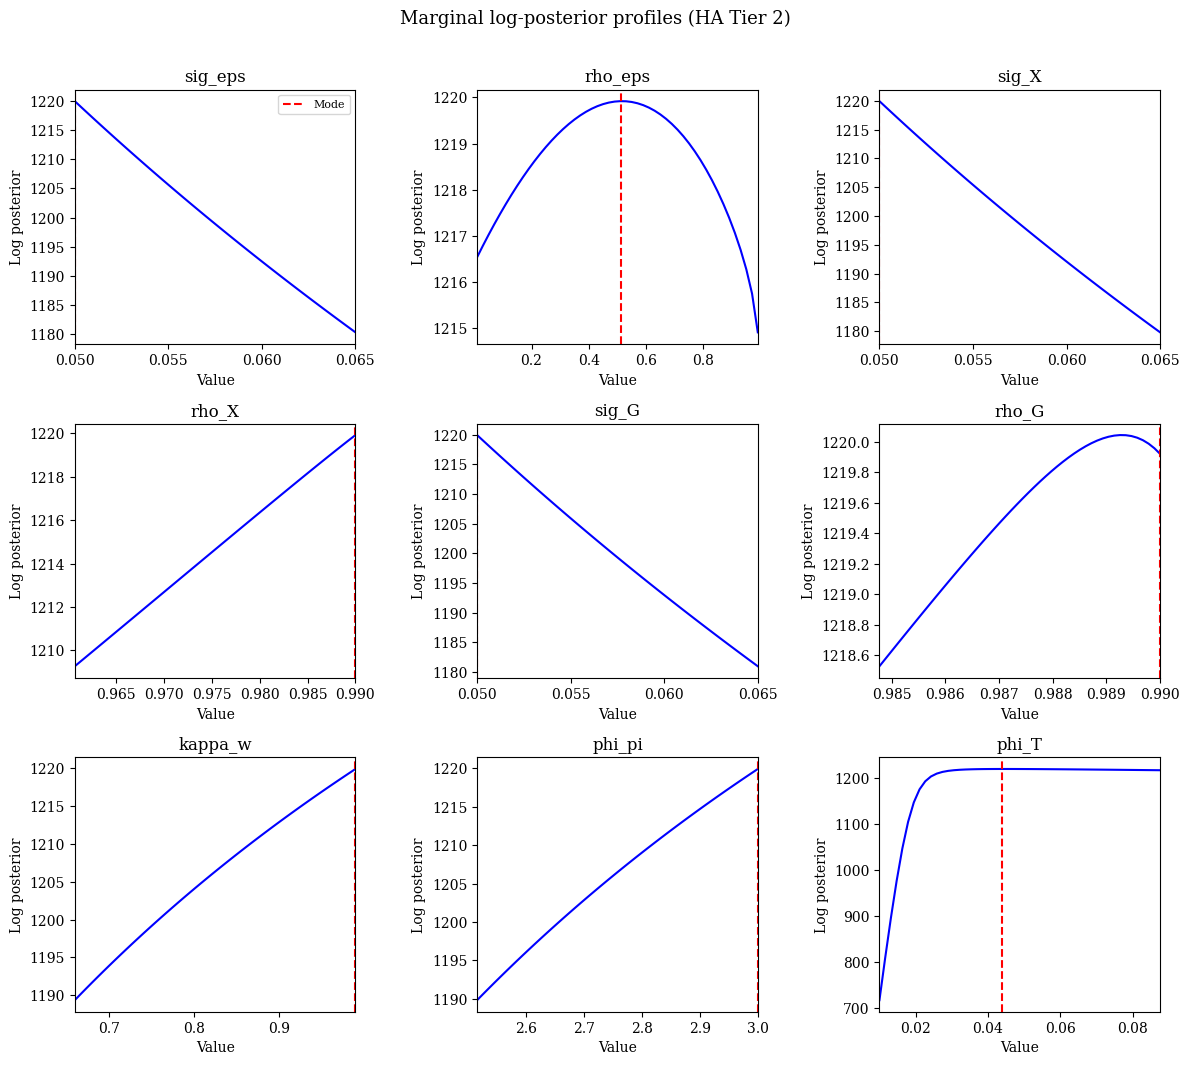

In [77]:
# --- Tier 2 marginal profiles (recomputes Jacobian at Tier 2 structural mode) ---
if result_ext is not None:
    # Recompute GE Jacobian at Tier 2 estimated structural params
    kw_t2, phipi_t2, phiT_t2 = result_ext.x[-3:]
    ss_ha_t2_dict = dict(ss_ha)
    ss_ha_t2_dict.update({'kappa_w': kw_t2, 'phi_pi': phipi_t2, 'phi_T': phiT_t2})
    ss_ha_t2 = SteadyStateDict(ss_ha_t2_dict, internals=ss_ha.internals)
    G_ha_t2 = model_ha.solve_jacobian(ss_ha_t2, unknowns, targets, exogenous, outputs=outputs, T=T)
    print(f"Tier 2 mode: kappa_w={kw_t2:.4f}, phi_pi={phipi_t2:.4f}, phi_T={phiT_t2:.4f}")

    # Logposterior with Jacobian caching (only recomputes when model params change)
    _G_cache = [result_ext.x[-len(params_est):].copy(), G_ha_t2]
    def logpost_t2(x):
        xp = x[-len(params_est):]
        if not np.allclose(xp, _G_cache[0]):
            ss_new = dict(ss_ha)
            ss_new.update({p: xp[j] for j, p in enumerate(params_est)})
            ss_new = SteadyStateDict(ss_new, internals=ss_ha.internals)
            _G_cache[1] = model_ha.solve_jacobian(
                ss_new, unknowns, targets, exogenous, outputs=outputs, T=T)
            _G_cache[0] = xp.copy()
        return loglik_f(x, data_real, outputs, shock_series, priors_ext, T, _G_cache[1])

    fig = plot_marginal_logpost(result_ext.x, names_ext, logpost_t2,
                                x_sd=sd_ext, bounds=bounds_ext,
                                title='Marginal log-posterior profiles (HA Tier 2)')
    plt.savefig('marginal_logpost_tier2.pdf', bbox_inches='tight')
    plt.show()
else:
    print("Tier 2 not estimated — skipping")

---
## 8. Post-Estimation Diagnostics

### 8.1 IRFs at Posterior Mode

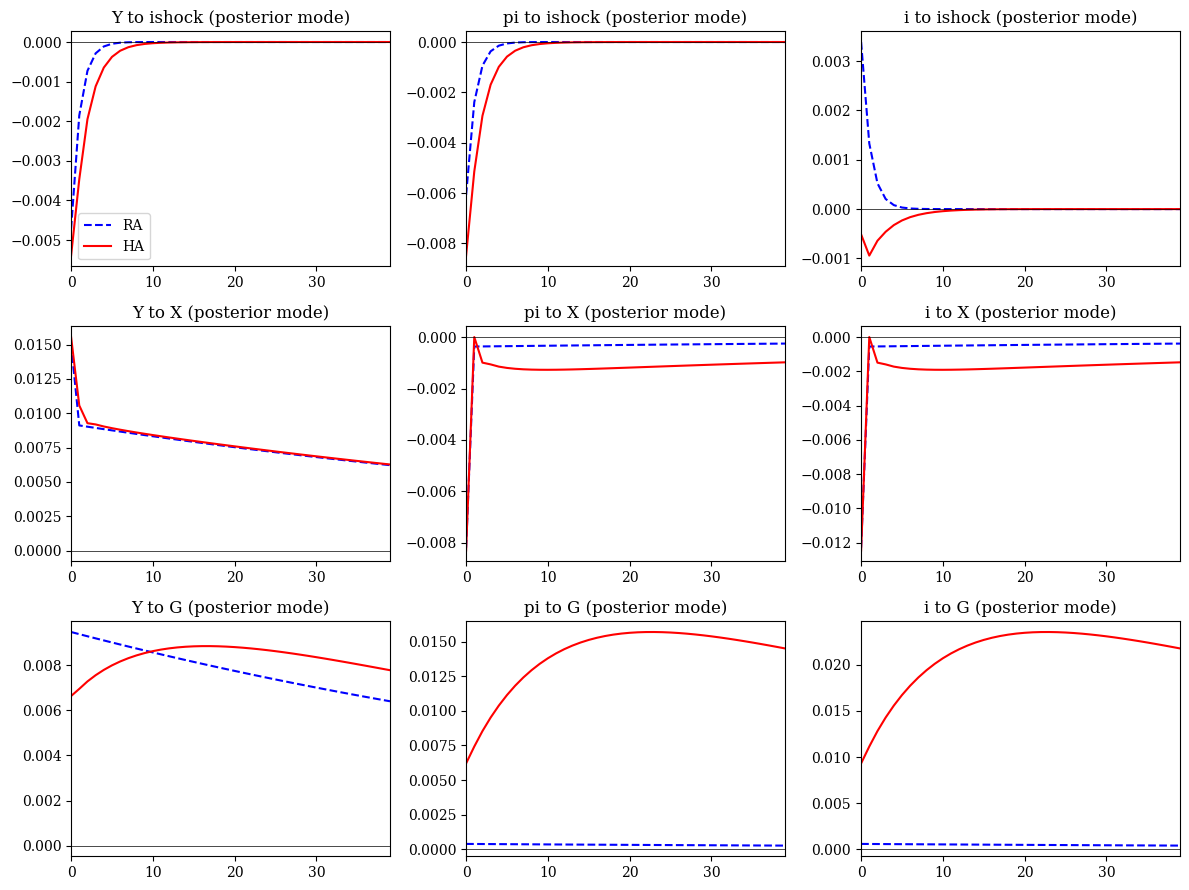

In [64]:
if USE_REAL_DATA:
    def irfs_at_mode(G, x, T, T_plot=40):
        sigmas, arcoefs, _ = get_shocks_arma(x, shock_series)
        irfs = {}
        for i, (sname, _) in enumerate(shock_series):
            sp = sigmas[i] * arcoefs[i]**np.arange(T)
            irfs[sname] = irf_make(G, sp, sname, ['pi','Y','i'], T)
        return irfs

    irfs_ra_m = irfs_at_mode(G_ra, results_shocks['ra'][0].x, T)
    irfs_ha_m = irfs_at_mode(G_ha, results_shocks['ha'][0].x, T)

    fig, axes = plt.subplots(3, 3, figsize=(12, 9))
    for j, s in enumerate(shock_list):
        for k, v in enumerate(['Y', 'pi', 'i']):
            ax = axes[j, k]
            ax.plot(irfs_ra_m[s][v][:40], 'b--', label='RA', lw=1.5)
            ax.plot(irfs_ha_m[s][v][:40], 'r-', label='HA', lw=1.5)
            ax.axhline(0, color='k', lw=0.5)
            ax.set_title(f'{v} to {s} (posterior mode)')
            if j==0 and k==0: ax.legend()
    plt.tight_layout()
    plt.savefig('irfs_posterior_mode.pdf', bbox_inches='tight')
    plt.show()

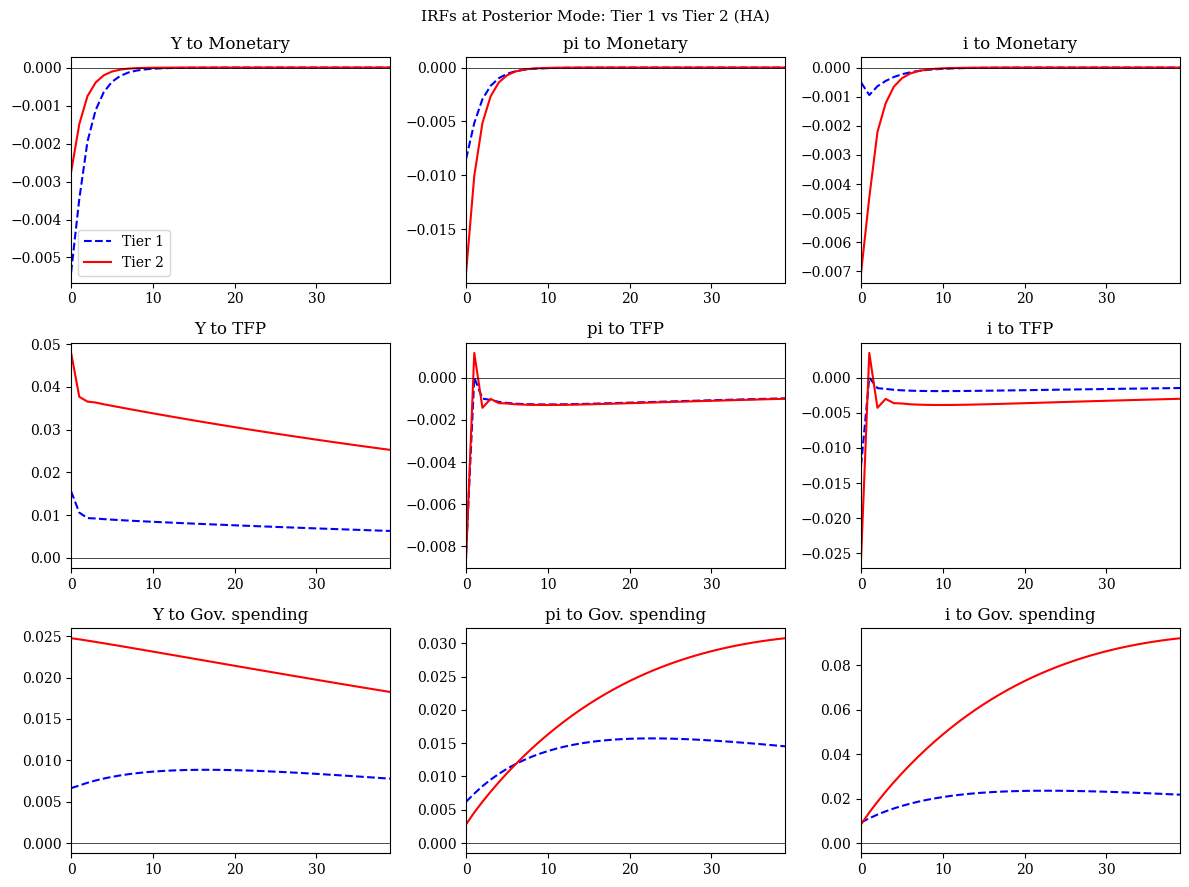

In [78]:
# --- Tier 2 IRFs: compare Tier 1 vs Tier 2 at posterior mode ---
if result_ext is not None:
    irfs_ha_t2 = irfs_at_mode(G_ha_t2, result_ext.x[:6], T)
    irfs_ha_t1 = irfs_at_mode(G_ha, results_shocks['ha'][0].x, T)

    fig, axes = plt.subplots(3, 3, figsize=(12, 9))
    for j, s in enumerate(shock_list):
        for k, v in enumerate(['Y', 'pi', 'i']):
            ax = axes[j, k]
            ax.plot(irfs_ha_t1[s][v][:40], 'b--', label='Tier 1', lw=1.5)
            ax.plot(irfs_ha_t2[s][v][:40], 'r-', label='Tier 2', lw=1.5)
            ax.axhline(0, color='k', lw=0.5)
            ax.set_title(f'{v} to {shock_labels[s]}')
            if j == 0 and k == 0: ax.legend()
    plt.suptitle('IRFs at Posterior Mode: Tier 1 vs Tier 2 (HA)', fontsize=11)
    plt.tight_layout()
    plt.savefig('irfs_tier2_vs_tier1.pdf', bbox_inches='tight')
    plt.show()

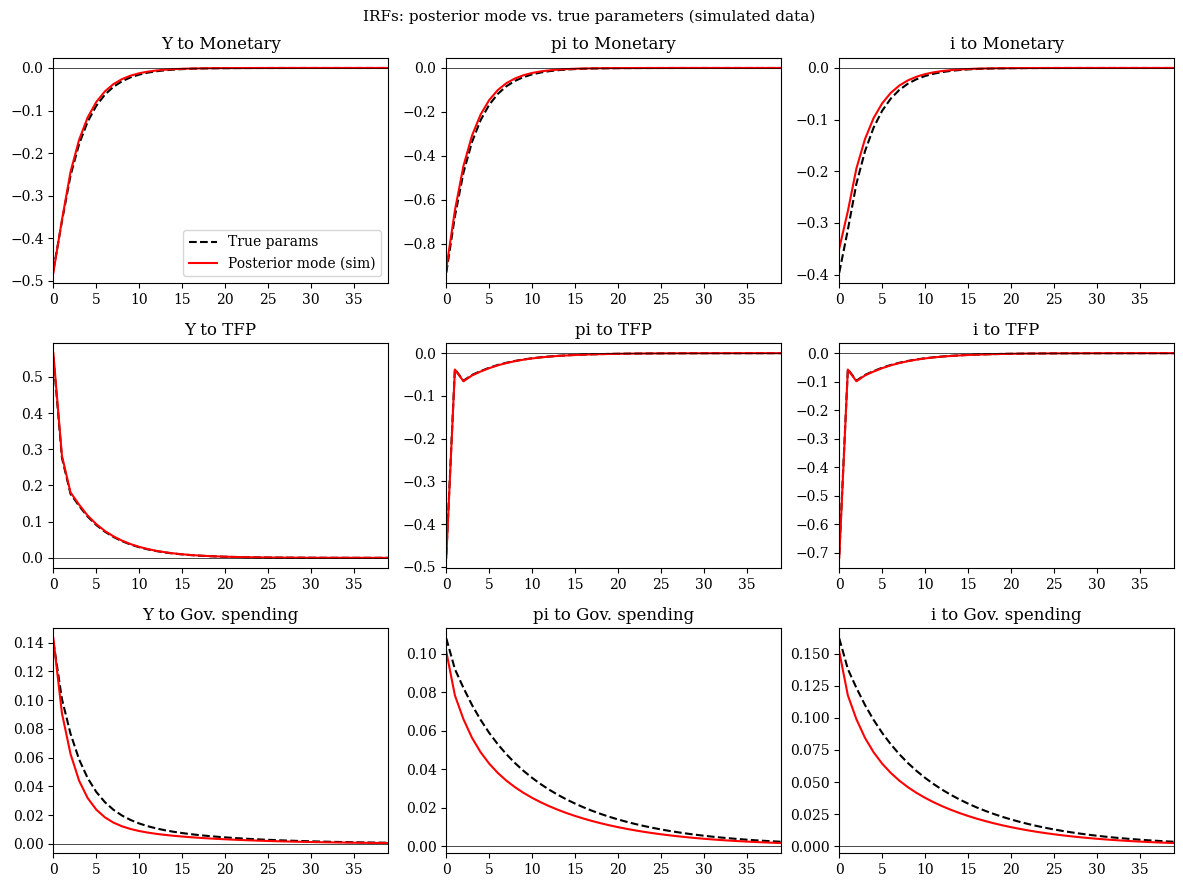

In [79]:
# IRFs at simulated-data posterior mode vs. true parameters
shock_labels = {'ishock': 'Monetary', 'X': 'TFP', 'G': 'Gov. spending'}

irfs_sim_mode = irfs_at_mode(G_ha, result_sim.x, T)
irfs_true     = irfs_at_mode(G_ha, x_true, T)

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for j, s in enumerate(shock_list):
    for k, v in enumerate(['Y', 'pi', 'i']):
        ax = axes[j, k]
        ax.plot(irfs_true[s][v][:40],     'k--', label='True params', lw=1.5)
        ax.plot(irfs_sim_mode[s][v][:40], 'r-',  label='Posterior mode (sim)', lw=1.5)
        ax.axhline(0, color='k', lw=0.5)
        ax.set_title(f'{v} to {shock_labels[s]}')
        if j == 0 and k == 0: ax.legend()
plt.suptitle('IRFs: posterior mode vs. true parameters (simulated data)', fontsize=11)
plt.tight_layout()
plt.savefig('irfs_simulated_mode.pdf', bbox_inches='tight')
plt.show()

### 8.2 Historical Shock Decomposition

In [80]:
def construct_stacked_A(As, To, To_out=None, sigma_e=None, sigma_o=None, reshape=True):
    Tm, O, E = As.shape
    if To_out is None: To_out = To
    A_full = np.zeros((To_out, O, To, E))
    for o in range(O):
        for it in range(To):
            iA = it if To <= To_out else it - (To - To_out)
            iAs = -min(iA, 0) if To > To_out else 0
            iA = max(iA, 0)
            sl = min(Tm, To_out - iA)
            for e in range(E):
                A_full[iA:iA+sl, o, it, e] = As[iAs:iAs+sl, o, e]
                if sigma_e is not None: A_full[iA:iA+sl, o, it, e] *= sigma_e[e]
                if sigma_o is not None: A_full[iA:iA+sl, o, it, e] /= sigma_o[o]
    return A_full.reshape((To_out*O, To*E)) if reshape else A_full

def back_out_shocks(As, y, sigma_e=None, preperiods=0):
    To, O = y.shape
    To_pre = To + preperiods
    A_full = construct_stacked_A(As, To=To_pre, To_out=To, sigma_e=sigma_e)
    eps = np.linalg.lstsq(A_full, y.reshape(To*O), rcond=None)[0].reshape((To_pre, As.shape[2]))
    A4 = construct_stacked_A(As, To=To_pre, To_out=To, sigma_e=sigma_e, reshape=False)
    Ds = np.sum(A4 * eps[np.newaxis, np.newaxis, :, :], axis=2)
    return eps[preperiods:], Ds

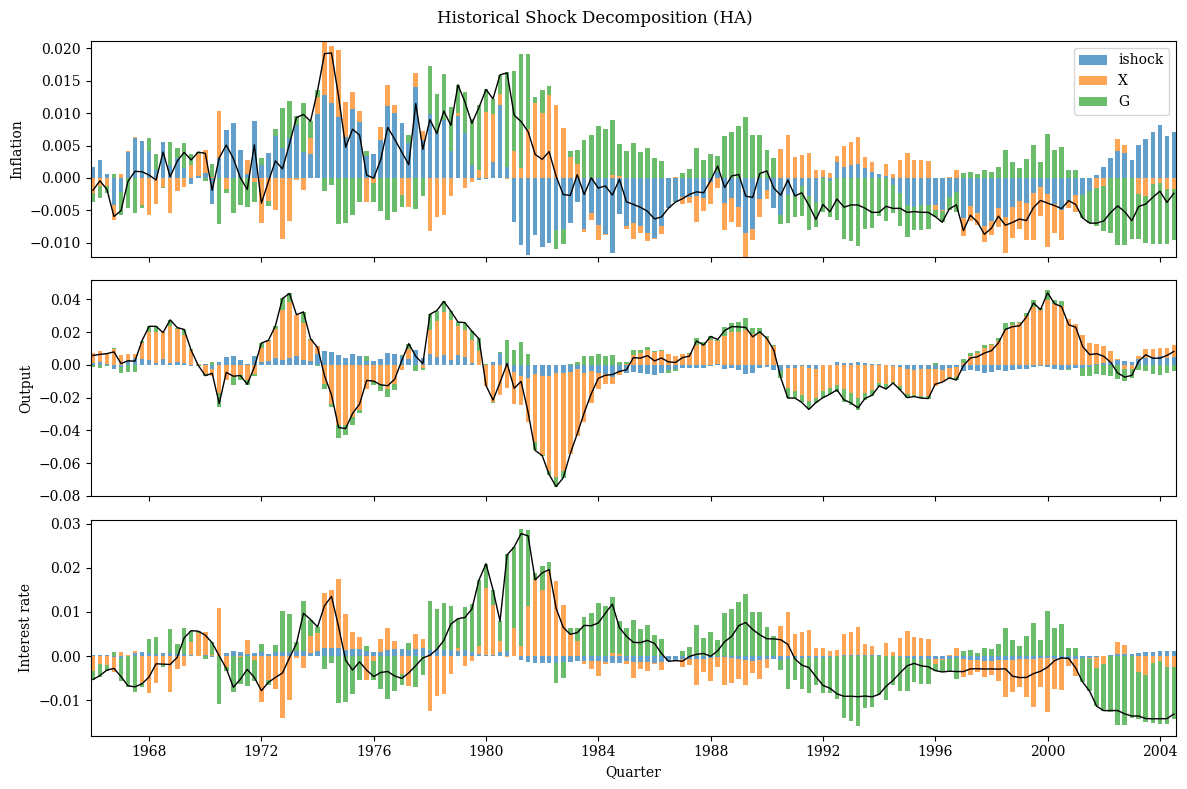

In [67]:
if USE_REAL_DATA:
    import pandas as pd
    x_est = results_shocks['ha'][0].x
    sigmas_est, arcoefs_est, macoefs_est = get_shocks_arma(x_est, shock_series)
    T_irf = T - 20
    As_est = step1_est(G_ha, arcoefs_est, macoefs_est, shock_series, outputs, T, T_irf, 3, 3)
    eps_hat, Ds = back_out_shocks(As_est, data_real, sigma_e=sigmas_est, preperiods=1)

    To = data_real.shape[0]
    quarters = pd.date_range('1966Q1', periods=To, freq='QS')

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for k, label in enumerate(['Inflation', 'Output', 'Interest rate']):
        ax = axes[k]
        bp, bn = np.zeros(To), np.zeros(To)
        for e in range(3):
            c = Ds[:, k, e]
            ax.bar(quarters, np.maximum(c,0), bottom=bp, color=colors[e], alpha=0.7,
                   label=shock_list[e], width=60)
            ax.bar(quarters, np.minimum(c,0), bottom=bn, color=colors[e], alpha=0.7,
                   width=60)
            bp += np.maximum(c,0); bn += np.minimum(c,0)
        ax.plot(quarters, data_real[:, k], 'k-', lw=1)
        ax.set_ylabel(label)
        if k == 0: ax.legend()
    axes[-1].set_xlabel('Quarter')
    plt.suptitle('Historical Shock Decomposition (HA)')
    plt.tight_layout()
    plt.savefig('historical_decomposition.pdf', bbox_inches='tight')
    plt.show()

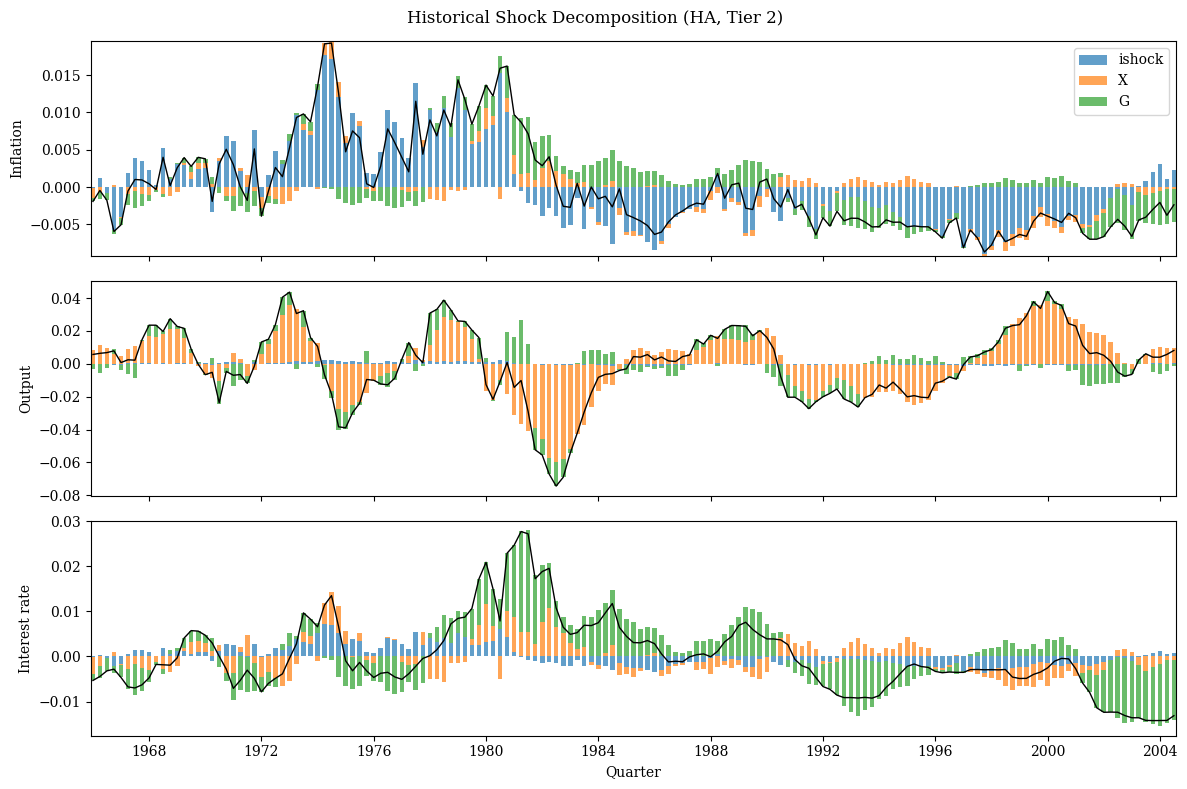

In [81]:
# --- Tier 2 Historical Decomposition ---
if result_ext is not None:
    import pandas as pd
    sigmas_t2, arcoefs_t2, macoefs_t2 = get_shocks_arma(result_ext.x[:6], shock_series)
    T_irf = T - 20
    As_t2 = step1_est(G_ha_t2, arcoefs_t2, macoefs_t2, shock_series, outputs, T, T_irf, 3, 3)
    eps_t2, Ds_t2 = back_out_shocks(As_t2, data_real, sigma_e=sigmas_t2, preperiods=1)

    To = data_real.shape[0]
    quarters = pd.date_range('1966Q1', periods=To, freq='QS')

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for k, label in enumerate(['Inflation', 'Output', 'Interest rate']):
        ax = axes[k]
        bp, bn = np.zeros(To), np.zeros(To)
        for e in range(3):
            c = Ds_t2[:, k, e]
            ax.bar(quarters, np.maximum(c, 0), bottom=bp, color=colors[e], alpha=0.7,
                   label=shock_list[e], width=60)
            ax.bar(quarters, np.minimum(c, 0), bottom=bn, color=colors[e], alpha=0.7, width=60)
            bp += np.maximum(c, 0); bn += np.minimum(c, 0)
        ax.plot(quarters, data_real[:, k], 'k-', lw=1)
        ax.set_ylabel(label)
        if k == 0: ax.legend()
    axes[-1].set_xlabel('Quarter')
    plt.suptitle('Historical Shock Decomposition (HA, Tier 2)')
    plt.tight_layout()
    plt.savefig('historical_decomposition_tier2.pdf', bbox_inches='tight')
    plt.show()

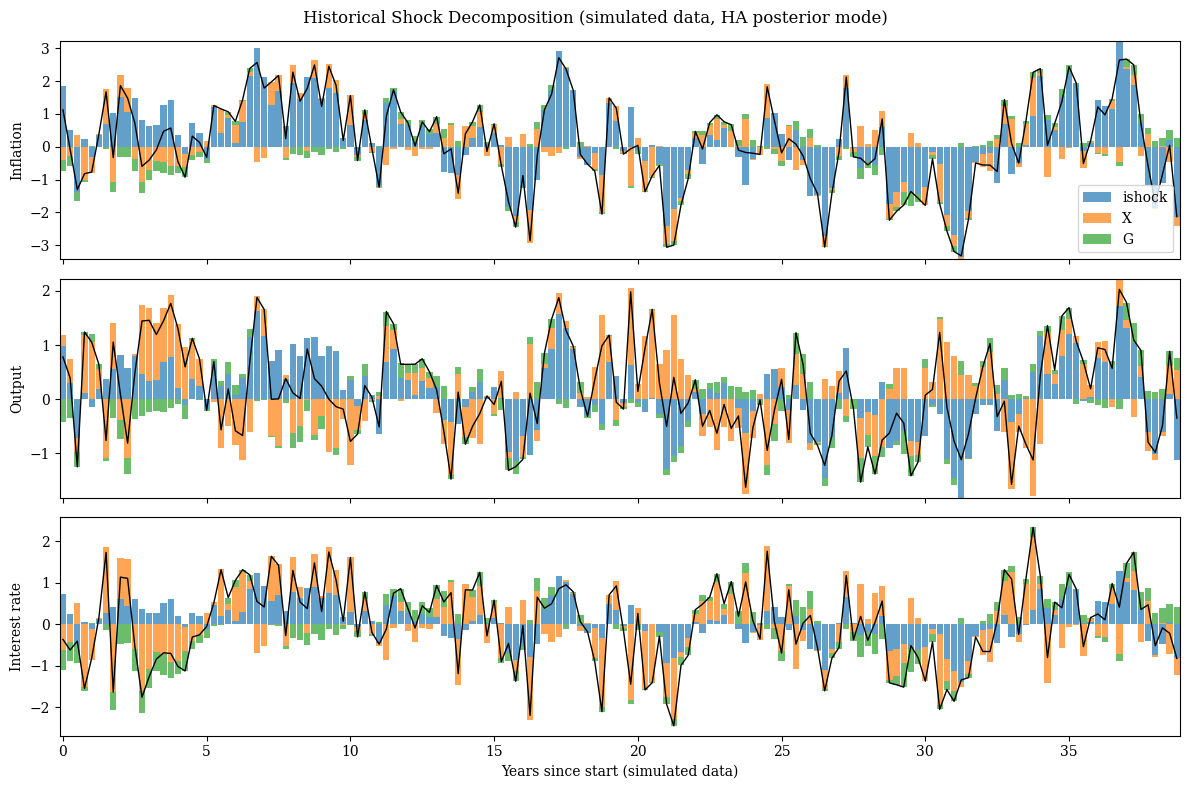

In [68]:
# Historical decomposition on simulated data
sigmas_sim, arcoefs_sim, macoefs_sim = get_shocks_arma(result_sim.x, shock_series)
T_irf = T - 20
As_sim = step1_est(G_ha, arcoefs_sim, macoefs_sim, shock_series, outputs, T, T_irf, 3, 3)
eps_sim, Ds_sim = back_out_shocks(As_sim, data_simul, sigma_e=sigmas_sim, preperiods=1)

To_sim = data_simul.shape[0]
years = np.arange(To_sim) / 4  # x-axis in years since start

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for k, label in enumerate(['Inflation', 'Output', 'Interest rate']):
    ax = axes[k]
    bp, bn = np.zeros(To_sim), np.zeros(To_sim)
    for e in range(3):
        c = Ds_sim[:, k, e]
        ax.bar(years, np.maximum(c,0), bottom=bp, color=colors[e], alpha=0.7,
               label=shock_list[e], width=0.22)
        ax.bar(years, np.minimum(c,0), bottom=bn, color=colors[e], alpha=0.7,
               width=0.22)
        bp += np.maximum(c,0); bn += np.minimum(c,0)
    ax.plot(years, data_simul[:, k], 'k-', lw=1)
    ax.set_ylabel(label)
    if k == 0: ax.legend()
axes[-1].set_xlabel('Years since start (simulated data)')
plt.suptitle('Historical Shock Decomposition (simulated data, HA posterior mode)')
plt.tight_layout()
plt.savefig('historical_decomposition_sim.pdf', bbox_inches='tight')
plt.show()

### 8.3 Forecast Error Variance Decomposition

FEVD at HA Posterior Mode

Horizon 1Q:
                     MP      TFP      Gov
  pi             40.1%   38.5%   21.4%
  Y               9.2%   76.8%   14.0%
  i               0.1%   64.2%   35.7%

Horizon 4Q:
                     MP      TFP      Gov
  pi             25.1%   16.2%   58.7%
  Y               6.0%   67.8%   26.2%
  i               0.2%   21.6%   78.1%

Horizon 8Q:
                     MP      TFP      Gov
  pi             11.5%    7.9%   80.6%
  Y               3.5%   62.2%   34.4%
  i               0.1%    8.9%   91.0%

Horizon 20Q:
                     MP      TFP      Gov
  pi              3.1%    2.7%   94.2%
  Y               1.5%   53.3%   45.1%
  i               0.0%    2.8%   97.2%


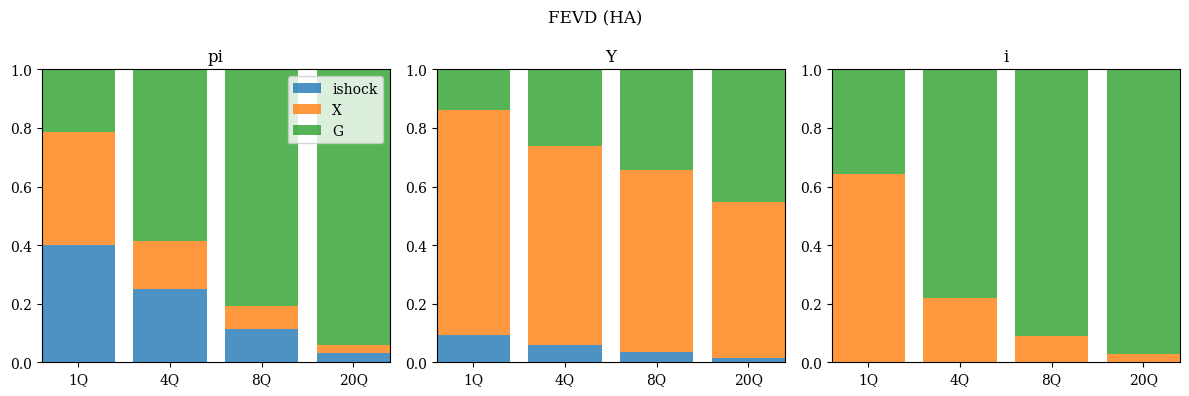

In [69]:
def compute_fevd(As, sigmas, horizons=[1,4,8,20]):
    Tm, O, E = As.shape
    results = {}
    for h in horizons:
        vz = np.zeros((O, E))
        for e in range(E):
            for s in range(min(h, Tm)):
                vz[:, e] += sigmas[e]**2 * As[s, :, e]**2
        results[h] = vz / vz.sum(axis=1, keepdims=True)
    return results

if USE_REAL_DATA:
    fevd = compute_fevd(As_est, sigmas_est)
    print("FEVD at HA Posterior Mode")
    for h in [1, 4, 8, 20]:
        print(f"\nHorizon {h}Q:")
        print(f"  {'':12} {'MP':>8} {'TFP':>8} {'Gov':>8}")
        for k, o in enumerate(outputs):
            print(f"  {o:<12} {fevd[h][k,0]:>7.1%} {fevd[h][k,1]:>7.1%} {fevd[h][k,2]:>7.1%}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for k, o in enumerate(outputs):
        ax = axes[k]
        bot = np.zeros(4)
        for e in range(3):
            v = [fevd[h][k,e] for h in [1,4,8,20]]
            ax.bar(range(4), v, bottom=bot, color=colors[e], label=shock_list[e], alpha=0.8)
            bot += v
        ax.set_xticks(range(4)); ax.set_xticklabels(['1Q','4Q','8Q','20Q'])
        ax.set_title(o); ax.set_ylim(0,1)
        if k==0: ax.legend()
    plt.suptitle('FEVD (HA)')
    plt.tight_layout()
    plt.savefig('fevd_ha.pdf', bbox_inches='tight')
    plt.show()

FEVD at HA Tier 2 Posterior Mode

Horizon 1Q:
                     MP      TFP      Gov
  pi             81.7%   16.5%    1.8%
  Y               0.3%   78.8%   21.0%
  i               6.4%   84.5%    9.2%

Horizon 4Q:
                     MP      TFP      Gov
  pi             70.8%   11.1%   18.1%
  Y               0.1%   72.5%   27.4%
  i               4.0%   36.4%   59.7%

Horizon 8Q:
                     MP      TFP      Gov
  pi             41.2%    6.9%   51.9%
  Y               0.1%   70.8%   29.1%
  i               1.2%   11.6%   87.2%

Horizon 20Q:
                     MP      TFP      Gov
  pi              8.6%    1.8%   89.7%
  Y               0.0%   69.2%   30.8%
  i               0.2%    1.9%   97.9%


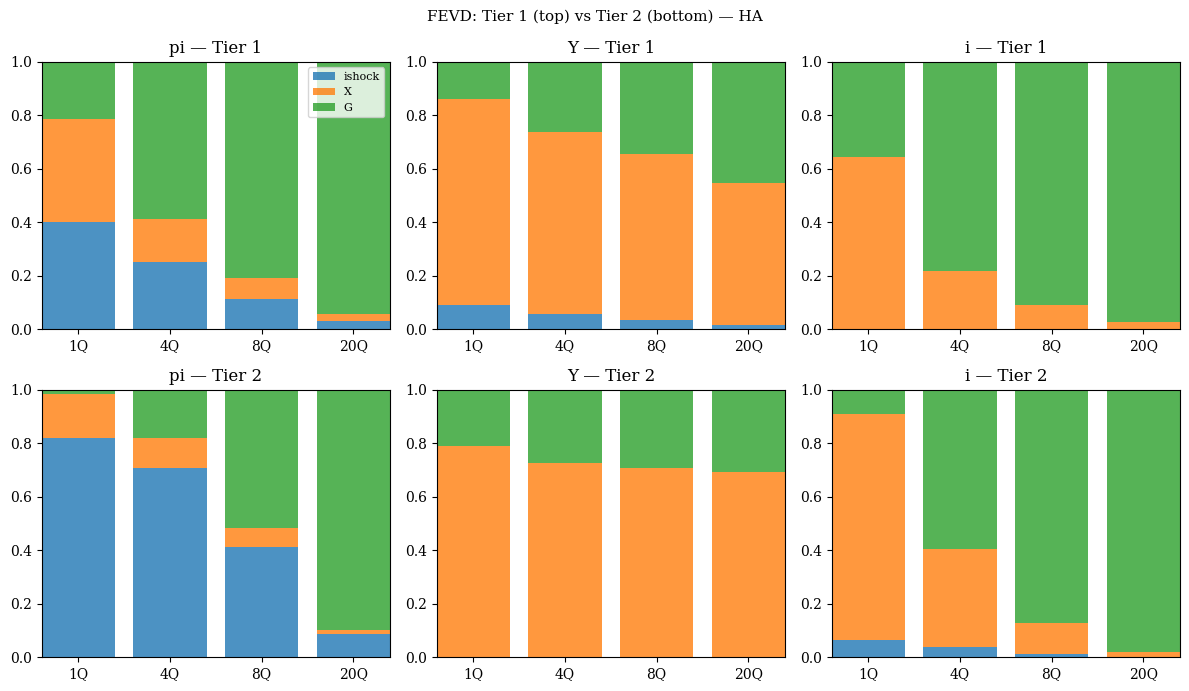

In [82]:
# --- Tier 2 FEVD ---
if result_ext is not None:
    fevd_t2 = compute_fevd(As_t2, sigmas_t2)

    print("FEVD at HA Tier 2 Posterior Mode")
    for h in [1, 4, 8, 20]:
        print(f"\nHorizon {h}Q:")
        print(f"  {'':12} {'MP':>8} {'TFP':>8} {'Gov':>8}")
        for k, o in enumerate(outputs):
            print(f"  {o:<12} {fevd_t2[h][k,0]:>7.1%} {fevd_t2[h][k,1]:>7.1%} {fevd_t2[h][k,2]:>7.1%}")

    # Side-by-side: Tier 1 vs Tier 2
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    for k, o in enumerate(outputs):
        for row, (f_src, lbl) in enumerate([(fevd, 'Tier 1'), (fevd_t2, 'Tier 2')]):
            ax = axes[row, k]
            bot = np.zeros(4)
            for e in range(3):
                v = [f_src[h][k, e] for h in [1, 4, 8, 20]]
                ax.bar(range(4), v, bottom=bot, color=colors[e], label=shock_list[e], alpha=0.8)
                bot += v
            ax.set_xticks(range(4)); ax.set_xticklabels(['1Q', '4Q', '8Q', '20Q'])
            ax.set_title(f'{o} — {lbl}'); ax.set_ylim(0, 1)
            if k == 0 and row == 0: ax.legend(fontsize=8)
    plt.suptitle('FEVD: Tier 1 (top) vs Tier 2 (bottom) — HA', fontsize=11)
    plt.tight_layout()
    plt.savefig('fevd_tier2_vs_tier1.pdf', bbox_inches='tight')
    plt.show()

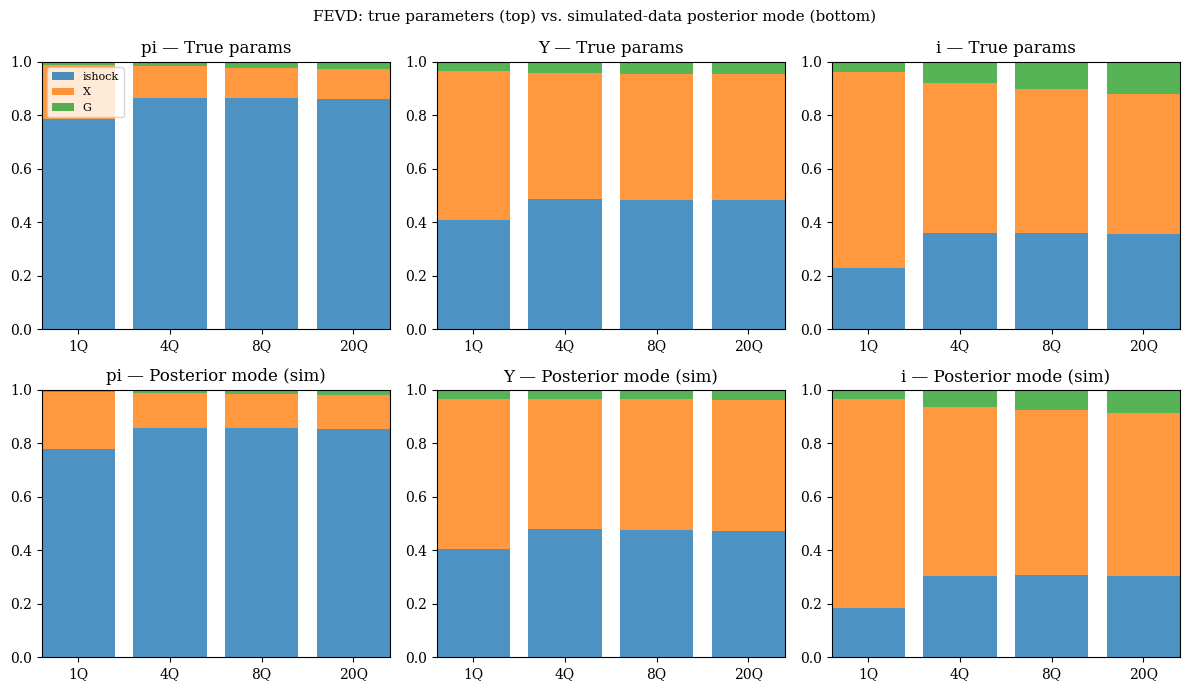

In [83]:
# FEVD on simulated data — estimated vs. true parameters side by side
fevd_sim  = compute_fevd(As_sim,  sigmas_sim)

T_irf = T - 20
As_true = step1_est(G_ha,
                    np.array([rhos_true[s] for s, _ in shock_series]),
                    np.zeros(3),
                    shock_series, outputs, T, T_irf, 3, 3)
sigmas_true_arr = np.array([sigs_true[s] for s, _ in shock_series])
fevd_true = compute_fevd(As_true, sigmas_true_arr)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
horizons_plot = [1, 4, 8, 20]
for k, o in enumerate(outputs):
    for row, (fevd_src, lbl) in enumerate([(fevd_true, 'True params'), (fevd_sim, 'Posterior mode (sim)')]):
        ax = axes[row, k]
        bot = np.zeros(4)
        for e in range(3):
            v = [fevd_src[h][k, e] for h in horizons_plot]
            ax.bar(range(4), v, bottom=bot, color=colors[e], label=shock_list[e], alpha=0.8)
            bot += v
        ax.set_xticks(range(4)); ax.set_xticklabels(['1Q','4Q','8Q','20Q'])
        ax.set_title(f'{o} — {lbl}'); ax.set_ylim(0, 1)
        if k == 0 and row == 0: ax.legend(fontsize=8)
plt.suptitle('FEVD: true parameters (top) vs. simulated-data posterior mode (bottom)', fontsize=11)
plt.tight_layout()
plt.savefig('fevd_simulated.pdf', bbox_inches='tight')
plt.show()

### 8.4 Cross-Specification Comparison Figures

Four-way IRF comparison (RA Tier 1, True DGP, HA Tier 1, HA Tier 2) and three-way HVD comparison (Simulated, HA Tier 1, HA Tier 2).

In [ ]:
# --- 4-way IRF comparison: RA T1, True DGP, HA T1, HA T2 ---
if result_ext is not None:
    shock_labels = {'ishock': 'Monetary', 'X': 'TFP', 'G': 'Gov. spending'}

    # Reuse existing IRF variables
    irfs_ra_t1  = irfs_at_mode(G_ra, results_shocks['ra'][0].x, T)
    irfs_true   = irfs_at_mode(G_ha, x_true, T)
    irfs_ha_t1  = irfs_at_mode(G_ha, results_shocks['ha'][0].x, T)
    irfs_ha_t2  = irfs_at_mode(G_ha_t2, result_ext.x[:6], T)

    fig, axes = plt.subplots(3, 3, figsize=(14, 10))
    for j, s in enumerate(shock_list):
        for k, v in enumerate(['Y', 'pi', 'i']):
            ax = axes[j, k]
            ax.plot(irfs_ra_t1[s][v][:40], 'b--',  lw=1.5, label='RA Tier 1')
            ax.plot(irfs_true[s][v][:40],  ':',     lw=1.5, color='gray', label='True DGP')
            ax.plot(irfs_ha_t1[s][v][:40], 'r-',    lw=1.5, label='HA Tier 1')
            ax.plot(irfs_ha_t2[s][v][:40], 'g-.',   lw=1.5, label='HA Tier 2')
            ax.axhline(0, color='k', lw=0.5)
            ax.set_title(f'{v} to {shock_labels[s]}')
            if j == 0 and k == 0: ax.legend(fontsize=8)
    plt.suptitle('IRFs at Posterior Mode: RA T1 vs True DGP vs HA T1 vs HA T2', fontsize=11)
    plt.tight_layout()
    plt.savefig('irfs_4way_comparison.pdf', bbox_inches='tight')
    plt.show()
else:
    print("Tier 2 not estimated — skipping 4-way IRF comparison")

In [ ]:
# --- 3-way HVD comparison: Simulated, HA Tier 1, HA Tier 2 ---
import pandas as pd

if result_ext is not None:
    To = data_real.shape[0]
    To_sim = data_simul.shape[0]
    quarters = pd.date_range('1966Q1', periods=To, freq='QS')
    years_sim = np.arange(To_sim) / 4

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    obs_labels = [r'$\pi$', 'Y', 'i']

    fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharey='row')

    # Column 0: Simulated data (HA at estimated-from-simulated params)
    for k in range(3):
        ax = axes[k, 0]
        bp, bn = np.zeros(To_sim), np.zeros(To_sim)
        for e in range(3):
            c = Ds_sim[:, k, e]
            ax.bar(years_sim, np.maximum(c,0), bottom=bp, color=colors[e], alpha=0.7,
                   label=shock_list[e], width=0.22)
            ax.bar(years_sim, np.minimum(c,0), bottom=bn, color=colors[e], alpha=0.7, width=0.22)
            bp += np.maximum(c,0); bn += np.minimum(c,0)
        ax.plot(years_sim, data_simul[:, k], 'k-', lw=0.8)
        ax.set_ylabel(obs_labels[k])
        if k == 0:
            ax.set_title('Simulated Data')
            ax.legend(fontsize=7)

    # Column 1: HA Tier 1 (real data)
    for k in range(3):
        ax = axes[k, 1]
        bp, bn = np.zeros(To), np.zeros(To)
        for e in range(3):
            c = Ds[:, k, e]
            ax.bar(quarters, np.maximum(c,0), bottom=bp, color=colors[e], alpha=0.7,
                   label=shock_list[e], width=60)
            ax.bar(quarters, np.minimum(c,0), bottom=bn, color=colors[e], alpha=0.7, width=60)
            bp += np.maximum(c,0); bn += np.minimum(c,0)
        ax.plot(quarters, data_real[:, k], 'k-', lw=0.8)
        if k == 0: ax.set_title('HA Tier 1 (Real Data)')

    # Column 2: HA Tier 2 (real data)
    for k in range(3):
        ax = axes[k, 2]
        bp, bn = np.zeros(To), np.zeros(To)
        for e in range(3):
            c = Ds_t2[:, k, e]
            ax.bar(quarters, np.maximum(c,0), bottom=bp, color=colors[e], alpha=0.7,
                   label=shock_list[e], width=60)
            ax.bar(quarters, np.minimum(c,0), bottom=bn, color=colors[e], alpha=0.7, width=60)
            bp += np.maximum(c,0); bn += np.minimum(c,0)
        ax.plot(quarters, data_real[:, k], 'k-', lw=0.8)
        if k == 0: ax.set_title('HA Tier 2 (Real Data)')

    plt.suptitle('Historical Shock Decomposition: Simulated vs HA Tier 1 vs HA Tier 2', fontsize=11)
    plt.tight_layout()
    plt.savefig('hvd_3way_comparison.pdf', bbox_inches='tight')
    plt.show()
else:
    print("Tier 2 not estimated — skipping 3-way HVD comparison")

---
## 9. Summary

- **Model**: Sticky-wage HANK with 3 AR(1) shocks, estimated via SSJ likelihood
- **Key result**: Ricardian equivalence breaks in HA, making $\phi_T$ identifiable
- **hetmacro verification**: EGM and Rouwenhorst match shade-econ to machine precision
- **Pipeline**: GE Jacobian computed once; each posterior evaluation is $\mathcal{O}(T)$ (Tier 1)